## **Analisis Exploratorio**
### **Desigualdad Educativa en Chile:** Análisis de Resultados PAES por Tipo de Establecimiento

#### **Nombres:** Lucas Chicao - Ninoska Cid - Isidora Gomez

#### **Curso**: IMT-2200 - Introduccion a la Ciencias de Datos

___
### **Contexto del proyecto:** 
La PAES es la prueba que miles de estudiantes chilenos rinden para acceder a la universidad, pero es un hecho que no todos cuentan con las mismas oportunidades educativas, ya que estas dependen del tipo de colegio en el que estudiaron.

En este proyecto, nos proponemos investigar si efectivamente hay diferencias en los puntajes de la PAES entre estudiantes de colegios públicos, subvencionados y privados, y también medir la magnitud de esas posibles diferencias.


### **Preguntas a responder:**
-¿Hay diferencias en los puntajes entre colegios públicos, subvencionados y privados?

-¿Qué tipo de colegio tiene mejores resultados en promedio?

-¿Qué tan grande es la brecha entre estos grupos?

-¿Existe correlación entre el tipo de establecimiento y las probabilidades de acceso a universidades tradicionales?

-¿Los resultados confirman las desigualdades educativas documentadas en otros estudios?

-...

### **Datos a usar:**
Los datos que usaremos en nuestro proyecto seran principalmente de base de datos de:

-DEMRE

-chiquillos si les parece aqui hay una base de datos para poder usar, si lo usamos eliminen este mensajito: https://www.kaggle.com/datasets/daniellopez01/admisionuescl

### **Analisis Exploratorio:**
En las siguientes lineas exploraremos los datos que ya obtuvimos y revisaremos como vamos en relacion con datos.
 

In [2]:
#LIBRERIAS A USAR
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
#...

# Analisis Exploratorio de la base de datos del DEMRE (2023 - 2025)

En este JupyterNotebook vamos  a aplicarle EDA a los archivos clasificados como Matricula de 2023 a 2025 de la Base de datos del DEMRE 

In [3]:
#CARGAR DATOS Y DF (INSCRIPCION)

'''
df_2023_postulacion_oferta = pd.read_excel(file_path1_Oferta)
df_2024_postulacion_oferta = pd.read_excel(file_path2_Oferta)
df_2025_postulacion_oferta = pd.read_excel(file_path3_Oferta)

df_postulaciones_ofertas = pd.concat(
    [df_2023_postulacion_oferta, df_2024_postulacion_oferta, df_2025_postulacion_oferta],
    ignore_index=True
)'''

base_path = os.path.dirname(os.getcwd())  # Esto sube un nivel desde 'Análisis Exploratorio'

file_path1 = os.path.join(base_path, 'DEMRE_bdd', '2023','Postulacion','PostulaciónySelección_Admisión2023', 'ArchivoD_Adm2023.csv')
file_path1_Oferta = os.path.join(base_path, 'DEMRE_bdd', '2023','Postulacion', 'OfertaAcadémica_Admisión2023.xlsx')

file_path2 = os.path.join(base_path, 'DEMRE_bdd', '2024','Postulacion','PostulaciónySelección_Admisión2024', 'ArchivoD_Adm2024.csv')
file_path2_Oferta = os.path.join(base_path, 'DEMRE_bdd', '2024','Postulacion', 'OfertaAcadémica_Admisión2024.xlsx')


file_path3 = os.path.join(base_path, 'DEMRE_bdd', '2025','Postulacion','Archivo D','PostulaciónySelección_Admisión2025','ArchivoD_Adm2025.csv')
file_path3_Oferta = os.path.join(base_path, 'DEMRE_bdd', '2025','Postulacion','Oferta Academica','OfertaAcadémica_Admisión2025.xlsx')

print(os.path.exists(file_path1))
print(os.path.exists(file_path1_Oferta))
print("----")
print(os.path.exists(file_path2))
print(os.path.exists(file_path2_Oferta))
print("----")
print(os.path.exists(file_path3))
print(os.path.exists(file_path3_Oferta))

df_2023_postulacion = pd.read_csv(file_path1, sep=';')
df_2024_postulacion = pd.read_csv(file_path2, sep=';')
df_2025_postulacion = pd.read_csv(file_path3, sep=';')

df_postulaciones_24_25 = pd.concat(
    [df_2024_postulacion, df_2025_postulacion],
    ignore_index=True
)

df_2023_postulacion_oferta = pd.read_excel(file_path1_Oferta)
df_2024_postulacion_oferta = pd.read_excel(file_path2_Oferta)
df_2025_postulacion_oferta = pd.read_excel(file_path3_Oferta)

df_postulaciones_ofertas = pd.concat(
    [df_2023_postulacion_oferta, df_2024_postulacion_oferta, df_2025_postulacion_oferta],
    ignore_index=True)



True
True
----
True
True
----
True
True


In [4]:
df_postulaciones_24_25

,ID_aux,ORDEN_PREF,COD_CARRERA_PREF,ESTADO_PREF,TIPO_PREF,PTJE_PREF
0,id_690126976014,1,51111,26,BEA,"709,9"
1,id_690126976014,2,51142,26,BEA,"708,25"
2,id_690126976014,4,56226,26,BEA,"647,1"
3,id_690126976014,5,12018,26,BEA,"701,8"
4,id_690126976014,6,49110,26,BEA,"647,1"
...,...,...,...,...,...,...
3454816,id_7666786545377,6,50101,35,REGULAR,NaN
3454817,id_7666786545377,7,23025,35,REGULAR,NaN
3454818,id_7666786545377,8,22101,35,REGULAR,NaN
3454819,id_7666786545377,9,25015,35,REGULAR,NaN


In [5]:
df_postulaciones_ofertas

,PROCESO,CODIGO,UNI_CODIGO,CARRERA,UNIVERSIDAD,REGION_CASA_MATRIZ,%_NOTAS,%_Ranking,%_LENG,%_MATE1,...,PACE,CAR_VACANTES_PACE,REG_CODIGO,CODIGO_CARRERA,NOMBRE_CARRERA,NOMBRE_UNIVERSIDAD,VACANTES_GENERO,IMPARTIDO_ANTES_2019,ACREDITADA_3AHNOS,CAR_CIENCIAS_TECNOLOGIA
0,2023,11001.0,11,ARQUITECTURA,UNIVERSIDAD DE CHILE,13,10,20,20,30,...,S,1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,11003.0,11,ACTUACIÃ“N TEATRAL,UNIVERSIDAD DE CHILE,13,10,20,30,15,...,S,1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,11004.0,11,DISEÃ‘O TEATRAL,UNIVERSIDAD DE CHILE,13,10,20,25,20,...,S,1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,11005.0,11,DISEÃ‘O,UNIVERSIDAD DE CHILE,13,10,30,25,25,...,S,2,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,11011.0,11,"ARTES VISUALES, LIC. EN ARTES CON MENCIÃ“N EN",UNIVERSIDAD DE CHILE,13,10,20,35,10,...,S,1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6136,2025,NaN,58,NaN,NaN,16,30,40,10,10,...,N,0,16,58149.0,OBSTETRICIA Y PUERICULTURA,UNIVERSIDAD ADVENTISTA DE CHILE,NaN,NaN,NaN,N
6137,2025,NaN,58,NaN,NaN,16,30,40,10,10,...,N,0,16,58150.0,NUTRICIÃ“N Y DIETÃ‰TICA,UNIVERSIDAD ADVENTISTA DE CHILE,NaN,NaN,NaN,N
6138,2025,NaN,58,NaN,NaN,16,30,40,10,10,...,N,0,16,58166.0,TERAPIA OCUPACIONAL,UNIVERSIDAD ADVENTISTA DE CHILE,NaN,NaN,NaN,N
6139,2025,NaN,58,NaN,NaN,16,30,40,10,10,...,N,0,16,58182.0,DERECHO,UNIVERSIDAD ADVENTISTA DE CHILE,NaN,NaN,NaN,N


In [6]:
#EXPLORACION - POSTULACIONES
print(f'Columnas : {df_postulaciones_24_25.columns}')
print('-----------')
print(f'Filas : {df_postulaciones_24_25.shape[0]}, Columnas : {df_postulaciones_24_25.shape[1]}') #Filas, Columnas
print('-----------\n')
print(df_postulaciones_24_25.info())
print('-----------') 


Columnas : Index(['ID_aux', 'ORDEN_PREF', 'COD_CARRERA_PREF', 'ESTADO_PREF', 'TIPO_PREF',
       'PTJE_PREF'],
      dtype='object')
-----------
Filas : 3454821, Columnas : 6
-----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454821 entries, 0 to 3454820
Data columns (total 6 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   ID_aux            object
 1   ORDEN_PREF        int64 
 2   COD_CARRERA_PREF  int64 
 3   ESTADO_PREF       int64 
 4   TIPO_PREF         object
 5   PTJE_PREF         object
dtypes: int64(3), object(3)
memory usage: 158.1+ MB
None
-----------


In [7]:
#EXPLORACION - OFERTAS
print(f'Columnas : {df_postulaciones_ofertas.columns}')
print('-----------')
print(f'Filas : {df_postulaciones_ofertas.shape[0]}, Columnas : {df_postulaciones_ofertas.shape[1]}') #Filas, Columnas
print('-----------\n')
print(df_postulaciones_ofertas.info())
print('-----------') 

Columnas : Index(['PROCESO', 'CODIGO', 'UNI_CODIGO', 'CARRERA', 'UNIVERSIDAD',
       'REGION_CASA_MATRIZ', '%_NOTAS', '%_Ranking', '%_LENG', '%_MATE1',
       '%_MATE2', '%_HYCS', '%_CIEN', 'EXIGE_MATE2', 'PROM_MINIMO_LENMAT',
       'PONDERADO_MINIMO', 'CDP_PUNTAJE_MIN_PEP', 'VACANTES_1SEM', 'SC_1S',
       'VACANTES_2SEM', 'SC_2S', 'RESTRINGE_SEXO', 'PRUEBA_ESPECIAL',
       'TIPO_PE', 'PONDERACION_PE', 'PO_ALTERNATIVA', 'MAX_POST_UNIV',
       'EXCLUYE_DESDE_PREFERENCIA', 'CDP_VACANTES_ESPECIALES', 'CAR_PEDAGOGIA',
       'CAR_MIN_RKG', 'CAR_SEL_PEDA', 'PACE', 'CAR_VACANTES_PACE',
       'REG_CODIGO', 'CODIGO_CARRERA', 'NOMBRE_CARRERA', 'NOMBRE_UNIVERSIDAD',
       'VACANTES_GENERO', 'IMPARTIDO_ANTES_2019', 'ACREDITADA_3AHNOS',
       'CAR_CIENCIAS_TECNOLOGIA'],
      dtype='object')
-----------
Filas : 6141, Columnas : 42
-----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6141 entries, 0 to 6140
Data columns (total 42 columns):
 #   Column                     Non-Null 

# LIMPIEZA DE DATOS - POSTULACIONES 2024 Y 2025

La base de datos de 2023 a 2024 sufrio un cambio de diseño, para poder realizar un mejor EDA tendria que aplicar una transformacion a la tabla en si y por el camino perderia datos 
o quizas seria demaciado tardado el realizarlo, es por ello que voy a manejarme solo con 2024 y 2025
Ademas, solo voy a considerar las 3 primeras elecciones de cada persona, es porque consideramos que apartir de la 3cera postulacion o lista, no esperamos que sea a algo a aspirar




In [8]:
#LIMPIEZA DE DATOS - POSTULACIONES
'''
Index(['ID_aux',
      'ORDEN_PREF', del 1 al 20
      'COD_CARRERA_PREF',
      'ESTADO_PREF',
      'TIPO_PREF',
      
       'PTJE_PREF'
       ],
      dtype='object')
'''
columnas_criticas = ['ID_aux', 'ORDEN_PREF','PTJE_PREF']

df_postulaciones_24_25_notnull = df_postulaciones_24_25.dropna(subset=columnas_criticas)

dfp_OP = df_postulaciones_24_25_notnull[df_postulaciones_24_25_notnull['ORDEN_PREF'].isin([1,2,3])]
dfp_OP_EP = dfp_OP[dfp_OP['ESTADO_PREF'].isin([9,10,11,15,17,19,20,22,23,24,25,26,27,28,29,30,31,32,35,36,40,41,42,51,52])]
dfp_OP_EP_TP = dfp_OP_EP[dfp_OP_EP['TIPO_PREF'].isin(['REGULAR','BEA','PACE','GENERO'])]

#-------------
df_clean = dfp_OP_EP_TP.copy()
prioridad = {'BEA': 1, 'REGULAR': 2, 'PACE': 3, 'GENERO': 4}
df_clean['prio'] = df_clean['TIPO_PREF'].replace(prioridad)
df_clean = df_clean.sort_values('prio').drop_duplicates(subset=['ID_aux','ORDEN_PREF','COD_CARRERA_PREF'], keep='first')
df_clean = df_clean.drop(columns=['prio'])

#Asi solo se muestran 3 postulaciones y no hasta 3 que llegaba a ocurrir

df_clean

C:\Users\lchicao\AppData\Local\Temp\ipykernel_29396\3857137270.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['prio'] = df_clean['TIPO_PREF'].replace(prioridad)


,ID_aux,ORDEN_PREF,COD_CARRERA_PREF,ESTADO_PREF,TIPO_PREF,PTJE_PREF
204926,id_9782597478299,2,29059,26,BEA,"708,9"
204927,id_9782597478299,3,13019,26,BEA,"654,05"
202835,id_9771597177146,1,53403,26,BEA,"742,9"
202836,id_9771597177146,3,51140,26,BEA,749
194249,id_9729597572984,1,14040,25,BEA,"740,9"
...,...,...,...,...,...,...
3454563,id_056902543888,1,11001,25,PACE,"1008,25"
3047712,id_5779557877965,2,16004,25,PACE,"804,03"
3047713,id_5779557877965,3,16014,25,PACE,"803,03"
3047940,id_5775557877534,3,18068,26,PACE,"913,721"


In [9]:
#LIMPIEZA DE DATOS - OFERTAS - En teoria esta no recibe ninguna limpieza de datos


In [10]:
#ESTADISTICAS DE DATOS (tipo promedios colegios, comunas con mas puntos, ...) 

# ORDEN_PREF
print('Cantidad de OrdenPreferencia:')
print(df_clean['ORDEN_PREF'].value_counts())
print('--------\n\n')


print("Codigo de carrera:")
print(df_clean['COD_CARRERA_PREF'].value_counts())
print('--------\n\n')

print("Estado de la preferencia:") 
print('ESTA ESTADISTICA NO ES REFERENCIAL YA QUE SI LA PREFERENCIA 1 ES TOMADA, EL RESTO NO PODRA SER TOMADA LO QUE IMPLICA QUE ESTA SE VE AFECTADA')
print(df_clean['ESTADO_PREF'].value_counts())
print('--------\n\n')

print("tipo de preferencia:")
print(df_clean['TIPO_PREF'].value_counts())
print('--------\n\n')

print("Puntaje Promedio de las preferencias:")
#print(df_clean['PTJE_PREF'].mean())
print('--------\n\n')




Cantidad de OrdenPreferencia:
ORDEN_PREF
1    345801
2    335227
3    314753
Name: count, dtype: int64
--------


Codigo de carrera:
COD_CARRERA_PREF
11045    10547
12058     9795
11083     9526
12039     8458
11055     6954
         ...  
39398        7
54304        7
54305        5
37103        4
36054        4
Name: count, Length: 2122, dtype: int64
--------


Estado de la preferencia:
ESTA ESTADISTICA NO ES REFERENCIAL YA QUE SI LA PREFERENCIA 1 ES TOMADA, EL RESTO NO PODRA SER TOMADA LO QUE IMPLICA QUE ESTA SE VE AFECTADA
ESTADO_PREF
25    466754
26    313988
24    215039
Name: count, dtype: int64
--------


tipo de preferencia:
TIPO_PREF
REGULAR    931296
BEA         60914
PACE         3571
Name: count, dtype: int64
--------


Puntaje Promedio de las preferencias:
--------




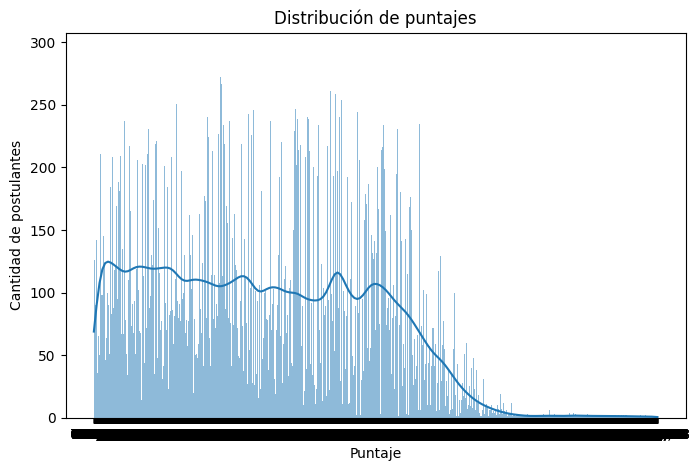

In [11]:
#VISUALIZACION DE LOS DATOS - PUNTAJE PREFERENCIA

plt.figure(figsize=(8,5))
sns.histplot(df_clean['PTJE_PREF'], bins=20, kde=True)
plt.title('Distribución de puntajes')
plt.xlabel('Puntaje')
plt.ylabel('Cantidad de postulantes')
plt.show()

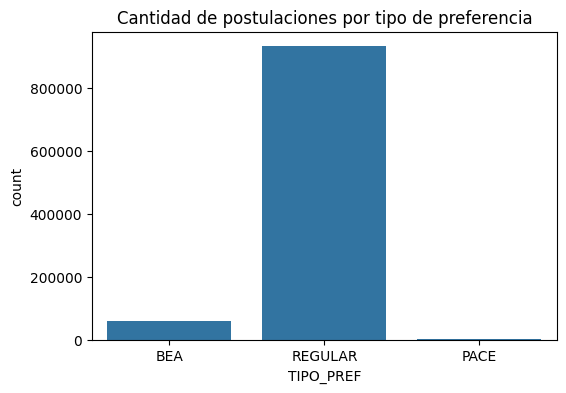

In [ ]:
#VISUALIZACION DE LOS DATOS - TIPO PREFERENCIA
plt.figure(figsize=(6,4))
sns.countplot(x='TIPO_PREF', data=df_clean)
plt.title('Cantidad de postulaciones por tipo de preferencia')
plt.show()


------------------------------------------------------------------------------------------------------------------------